In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import hashlib

import wandb
import numpy as np

sys.path.append(os.path.abspath(".."))

from src.utils.get_trainer import get_trainer
import src.models.xgb.xgb_cv_trainer as cv
from src.utils.print_duration import print_duration
from src.utils.logging import WandbLogger

In [2]:
# ===== User config =====
model_name = "xgb"
data_id = "027"

study_name = f"{model_name}-{data_id}"
storage_url = "sqlite:////home/hanse/kaggle/binary-bank/artifacts/optuna/optuna.db"

feature_dir = Path(f"../artifacts/features/base/{data_id}")
n_fold = 5
seed = 42

# どちらかを指定
n_trial = 16
n_custom = None

In [3]:
# get params
if n_trial is not None and n_custom is not None:
    raise ValueError("Set either n_trial or custom_params_json (not both).")
if n_trial is not None:
    params_id = f"trl{n_trial}"
    params_path = f"../artifacts/params/{study_name}/{params_id}.json"
elif n_custom is not None:
    params_id = f"cus{n_custom}"
    params_path = f"../artifacts/params/custom/{params_id}.json"
else:
    raise ValueError("Set n_trial or custom_params_json.")

with open(params_path, "r") as f:
    params = json.load(f)

print("Params path: ", params_path)
print("Params:\n", params)

Params path:  ../artifacts/params/xgb-027/trl16.json
Params:
 {'learning_rate': 0.02, 'max_depth': 10, 'min_child_weight': 37.16349389574308, 'colsample_bytree': 0.4317914542931692, 'subsample': 0.6442968084843167, 'reg_alpha': 0.009359347440143674, 'reg_lambda': 0.005483787866754371, 'n_jobs': 1, 'early_stopping_rounds': 200}


In [4]:
# ===== Save params and manifest =====
runs_root = Path("../runs")
run_id = f"{model_name}-{data_id}-{params_id}-s{seed}"
run_dir = runs_root / run_id
run_dir.mkdir(parents=True, exist_ok=True)

s = json.dumps(params, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
phash = hashlib.sha256(s.encode()).hexdigest()[:10]

manifest = {
    "run_id": run_id,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": model_name,
    "data_id": data_id,
    "seed": seed,
    "n_fold": n_fold,
    "feature_dir": str(feature_dir.resolve()),
    "phash": phash,
    "param_source": params_path,
    "run_dir": str(run_dir.resolve())
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)
with open(run_dir / "params.json", "w") as f:
    json.dump(params, f, indent=4)

print("manifest saved", run_dir / "manifest.json")
print("params saved", run_dir / "params.json")

manifest saved ../runs/xgb-027-trl16-s42/manifest.json
params saved ../runs/xgb-027-trl16-s42/params.json


In [5]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))
run = wandb.init(
    project="binary-bank",
    group=study_name,
    name=params_id,
    config={
        "data_id": data_id,
        "n_fold": n_fold,
        **params
    },
    tags=[model_name, "oof"]
)

wandb: Currently logged in as: kaitookano (kaitookano-waseda-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
# Training
trainer_class = get_trainer(model_name)
trainer = trainer_class(
    data_id,
    feature_dir,
    features=None,
    target="target",
    fold_col=None,
    weight_col=None,
    cat_cols=None,
    params=params,
    n_fold=n_fold,
    seed=seed,
    batch_rows=1_000_000,
    use_cudf=True
)

result = trainer.fit(
    loggers=[WandbLogger(run=run)]
)

CATS: 0 columns
Fold Col: 5fold-s42
===== Fold 1 / 5 =====
[0]	train-auc:0.96664	eval-auc:0.96537
[100]	train-auc:0.97688	eval-auc:0.97358
[200]	train-auc:0.97871	eval-auc:0.97442
[300]	train-auc:0.98021	eval-auc:0.97488
[400]	train-auc:0.98159	eval-auc:0.97517
[500]	train-auc:0.98284	eval-auc:0.97537
[600]	train-auc:0.98401	eval-auc:0.97549
[700]	train-auc:0.98505	eval-auc:0.97557
[800]	train-auc:0.98607	eval-auc:0.97562
[900]	train-auc:0.98696	eval-auc:0.97567
[1000]	train-auc:0.98787	eval-auc:0.97571
[1100]	train-auc:0.98867	eval-auc:0.97575
[1200]	train-auc:0.98939	eval-auc:0.97578
[1300]	train-auc:0.99011	eval-auc:0.97581
[1400]	train-auc:0.99081	eval-auc:0.97585
[1500]	train-auc:0.99144	eval-auc:0.97586
[1600]	train-auc:0.99208	eval-auc:0.97587
[1700]	train-auc:0.99269	eval-auc:0.97588
[1800]	train-auc:0.99326	eval-auc:0.97591
[1900]	train-auc:0.99377	eval-auc:0.97591
[2000]	train-auc:0.99427	eval-auc:0.97593
[2100]	train-auc:0.99473	eval-auc:0.97594
[2200]	train-auc:0.99518	eval

auc_f1,▁
auc_f2,▁
auc_f3,▁
auc_f4,▁
auc_f5,▁
eval/auc_f1,▁▃▄▄▄▆▇▇▇▇▇▇▇███████████████████████████
eval/auc_f2,▁▆▇▇▇▇▇▇▇▇██████████████████████████████
eval/auc_f3,▁▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████████████
eval/auc_f4,▁▃▇▇▇███████████████████████████████████
eval/auc_f5,▁▃▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
iter,▁▄▄▄▅▇█▂▂▂▅▅▆▁▂▃▃▄▄▅▆▆▇▇▇▁▂▃▃▃▇▁▁▂▄▄▆▆▇▇


Total CV Runtime: 00:36:10


In [8]:
# Save oof and test pred
np.save(run_dir / "oof.npy", result.oof)
np.save(run_dir / "test.npy", result.test_pred)

print(f"oof and test preds saved successfully in:\n{run_dir}")

oof and test preds saved successfully in:
../runs/xgb-027-trl16-s42


In [11]:
# Plot feature importance and get top columns
import matplotlib.pyplot as plt
import seaborn as sns

df = result.fi_mean
df = df[:100].to_pandas()

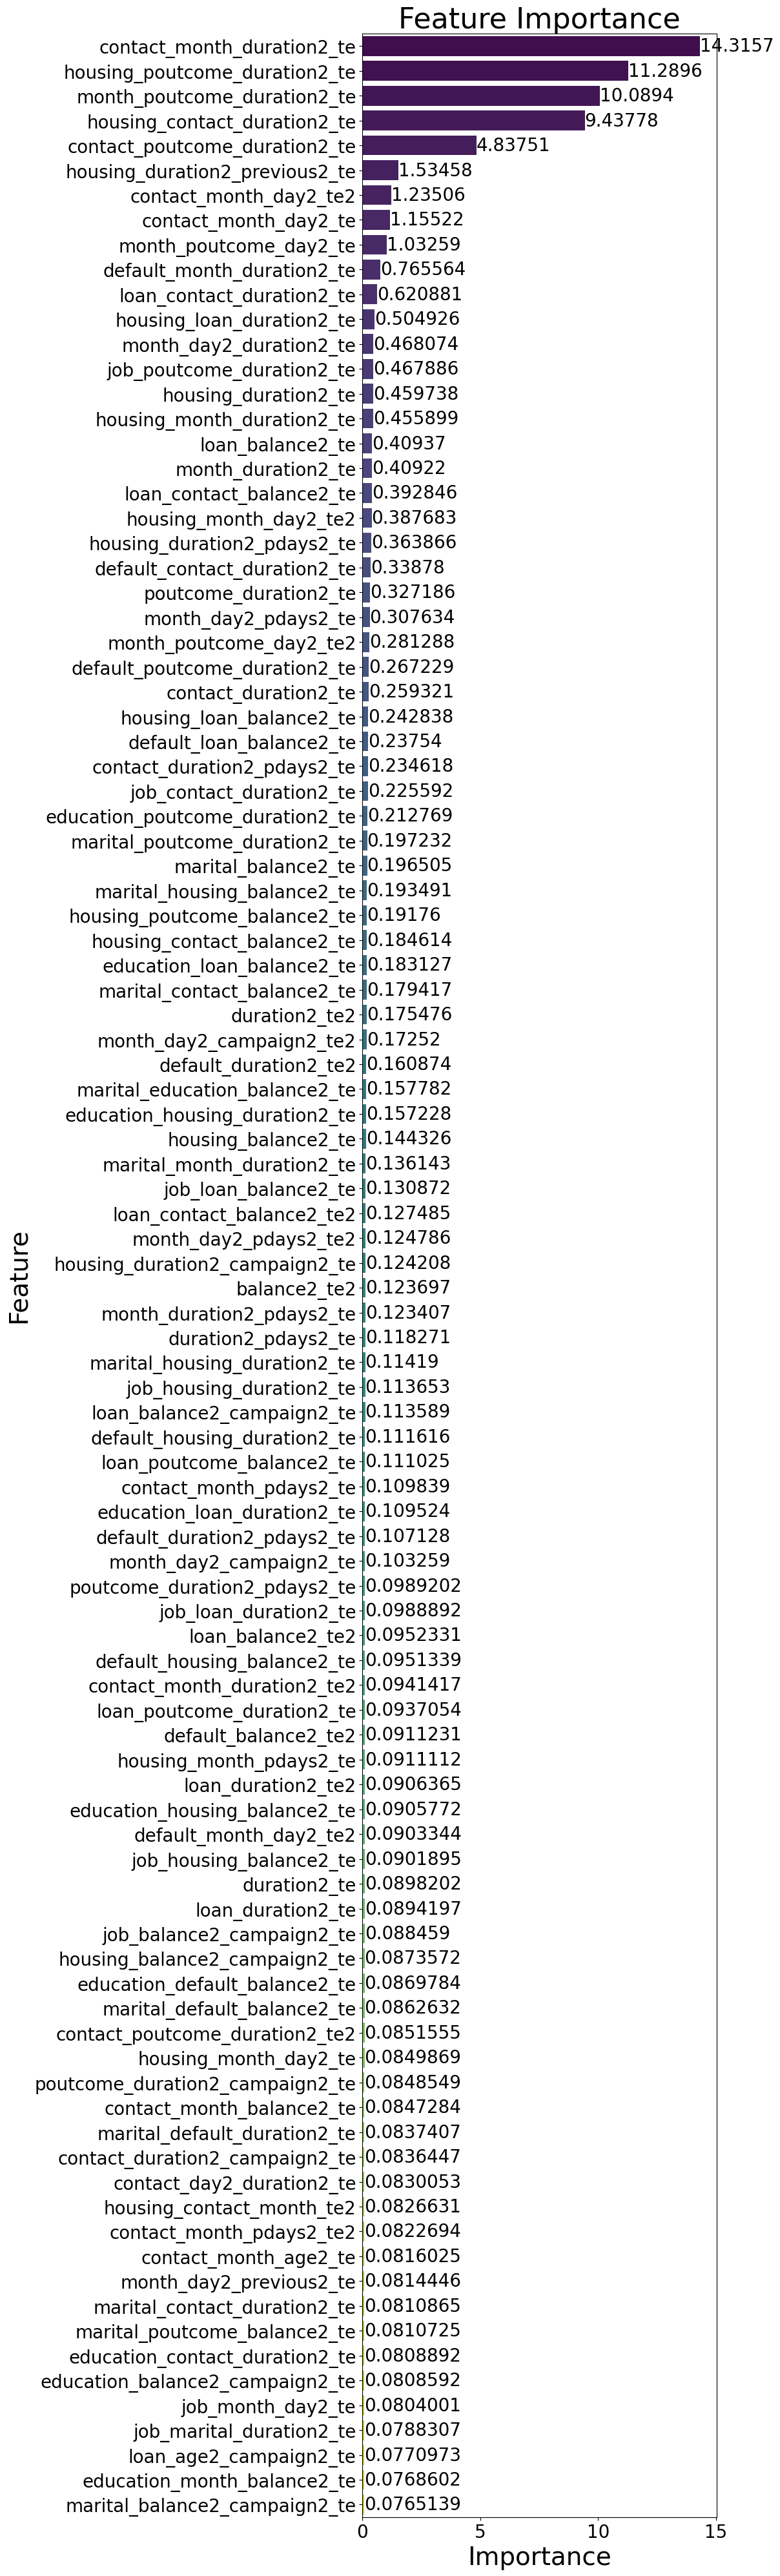

In [13]:
fig, ax = plt.subplots(figsize=(12, max(4, len(df)*0.4)))
sns.barplot(
    data=df,
    y="Feature",
    x="mean_ratio",
    orient="h",
    palette="flare",
    hue="Feature",
    ax=ax
)
for container in ax.containers:
    labels = ax.bar_label(container)
    for label in labels:
        label.set_fontsize(20)
plt.title("Feature Importance", fontsize=32)
plt.xlabel("Importance", fontsize=28)
plt.ylabel("Feature", fontsize=28)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
plt.tight_layout()
plt.show()

In [15]:
df = result.fi_mean
print(df[:, 0])

shape: (1_385,)
Series: 'Feature' [str]
[
	"contact_month_duration2_te"
	"housing_poutcome_duration2_te"
	"month_poutcome_duration2_te"
	"housing_contact_duration2_te"
	"contact_poutcome_duration2_te"
	…
	"contact_te2"
	"default_housing_te2"
	"contact_poutcome_te2"
	"housing_loan_te2"
	"poutcome_te2"
]


In [18]:
import pyarrow.dataset as ds
train_path = f"../artifacts/features/base/{data_id}/tr_df{data_id}-s{seed}.parquet"
schema = ds.dataset(train_path, format="parquet").schema
for f in schema:
    if f.name in df[:, 0] and "ce" in f.name:
        print(f.name)

balance2_te
job_balance2_te
marital_balance2_te
education_balance2_te
default_balance2_te
balance2_te2
job_balance2_te2
marital_balance2_te2
education_balance2_te2
default_balance2_te2
housing_balance2_te
loan_balance2_te
contact_balance2_te
month_balance2_te
poutcome_balance2_te
age2_balance2_te
balance2_day2_te
balance2_duration2_te
balance2_campaign2_te
balance2_pdays2_te
balance2_previous2_te
housing_balance2_te2
loan_balance2_te2
contact_balance2_te2
month_balance2_te2
poutcome_balance2_te2
age2_balance2_te2
balance2_day2_te2
balance2_duration2_te2
balance2_campaign2_te2
balance2_pdays2_te2
balance2_previous2_te2
job_marital_balance2_te
job_education_balance2_te
job_default_balance2_te
job_housing_balance2_te
job_loan_balance2_te
job_contact_balance2_te
job_month_balance2_te
job_marital_balance2_te2
job_education_balance2_te2
job_default_balance2_te2
job_housing_balance2_te2
job_loan_balance2_te2
job_contact_balance2_te2
job_month_balance2_te2
job_poutcome_balance2_te
job_age2_bal